---
title: "Handling missing data"
date: last-modified
toc: true
format:
  html:
    code-tools: true
    other-links:
      - text: Source Code
        href: https://github.com/mosesyhc/de300-2026wi/blob/main/class-notebooks/03-missing-data-class.ipynb
    link-external-newwindow: true
  ipynb: default
---

This document (briefly) introduces the concept, categorization, and treatment of missing data.

## Classical categories of missing data
If we know how the missing data are generated, so-called missing data mechanisms, we can take into account why data are missing in data analysis.

A particularly useful (and wide-known) framework for missingness categorizes missingness into the following three categories (Little and Rudin, 2019):

*Caveat... the category namings are... confusing*

**MCAR (missing completely at random):** how data are missing is independent with any aspect of the data

**MAR (missing at random):** how data are missing depends on **observed** quantities, so-called *predictors, or independent variables*
- e.g., a person with certain characteristics (known) may not answer certain questions on a survey, *imagine reporting salary for different socio-economic classes*
- e.g., for certain inputs, a simulation model may crash or produce nonsensical outputs

**MNAR (missing not at random):** how data are missing depends on the **unobserved** quantities
- e.g., a pollutant sensor can only detect particles that are $> 0.1\mu\mathrm{m}$  
- e.g., storm surges only occur in areas that get below the water level

Understanding the causes of missing data helps designing algorithms to handle missing data.  *However*, in reality, we often do not know the causes, or multiple causes exist in producing a data set.

**Cautionary note:** Where the data are missing matters, i.e., is a response value missing, is a predictor value missing, or do we not know what our analysis questions are yet?

## Treatment of missing data

**Starting with an example of "completing the data"**  

|                            |
|:--------------------------:|
|![gas-a](../img/gas-a.png)  |

|                            |Replace with the mean       |
|:--------------------------:|:--------------------------:|
|![gas-a](../img/gas-a.png)  |![gas-b](../img/gas-b.png)  |

|                            |Replace with the mean + noise|
|:--------------------------:|:--------------------------:|
|![gas-a](../img/gas-a.png)  |![gas-c](../img/gas-c.png)  |

|                            |Replace with the mean + noise + parameter uncertainty|
|:--------------------------:|:--------------------------:|
|![gas-a](../img/gas-a.png)  |![gas-d](../img/gas-d.png)  |

|                            |More information + replace with mean + noise|
|:--------------------------:|:--------------------------:|
|![gas-a](../img/gas-a.png)  |![gas-e](../img/gas-e.png)  |

|                            |Predictive mean matching |
|:--------------------------:|:--------------------------:|
|![gas-a](../img/gas-a.png)  |![gas-f](../img/gas-f.png)  |

**Example of missingness impacting analysis** from Daniel et al. (2012), reproducing Figure 4 in the paper:

|![mar-mnar](../img/mar-mnar.png)|
|:---:|
|Effect of missingness mechanism on data analysis.|


### General rules for treating missing data:  
- Under MCAR, focusing on complete cases or employing imputation methods tend to be sufficient.
- Under MAR, some methods are valid choices:
  - If the missingness is independent of the response *conditional* on the predictor, linear regression is still "valid".
  - Imputation methods tend to introduce biases, depending on the data analysis methods.
- Under MNAR, the missingness should be explicitly modeled.
  - e.g., censored observations in survival analysis.

## Imputation methods
We introduce a (limited) list of imputation methods in this section, using the `titanic` dataset as an example:

In [55]:
!pip install missingno miceforest #nineplot

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.precision', 3)

titanic = sns.load_dataset('titanic', cache=True, data_home='datasets/')

### Identifying missingness
We have covered some basic ways how to identify missingness in the EDA module.  Here is one other option with the help of `missingno`.

In [57]:
# !pip install missingno
# in case you need to install the package

import missingno as msno


titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


<Axes: >

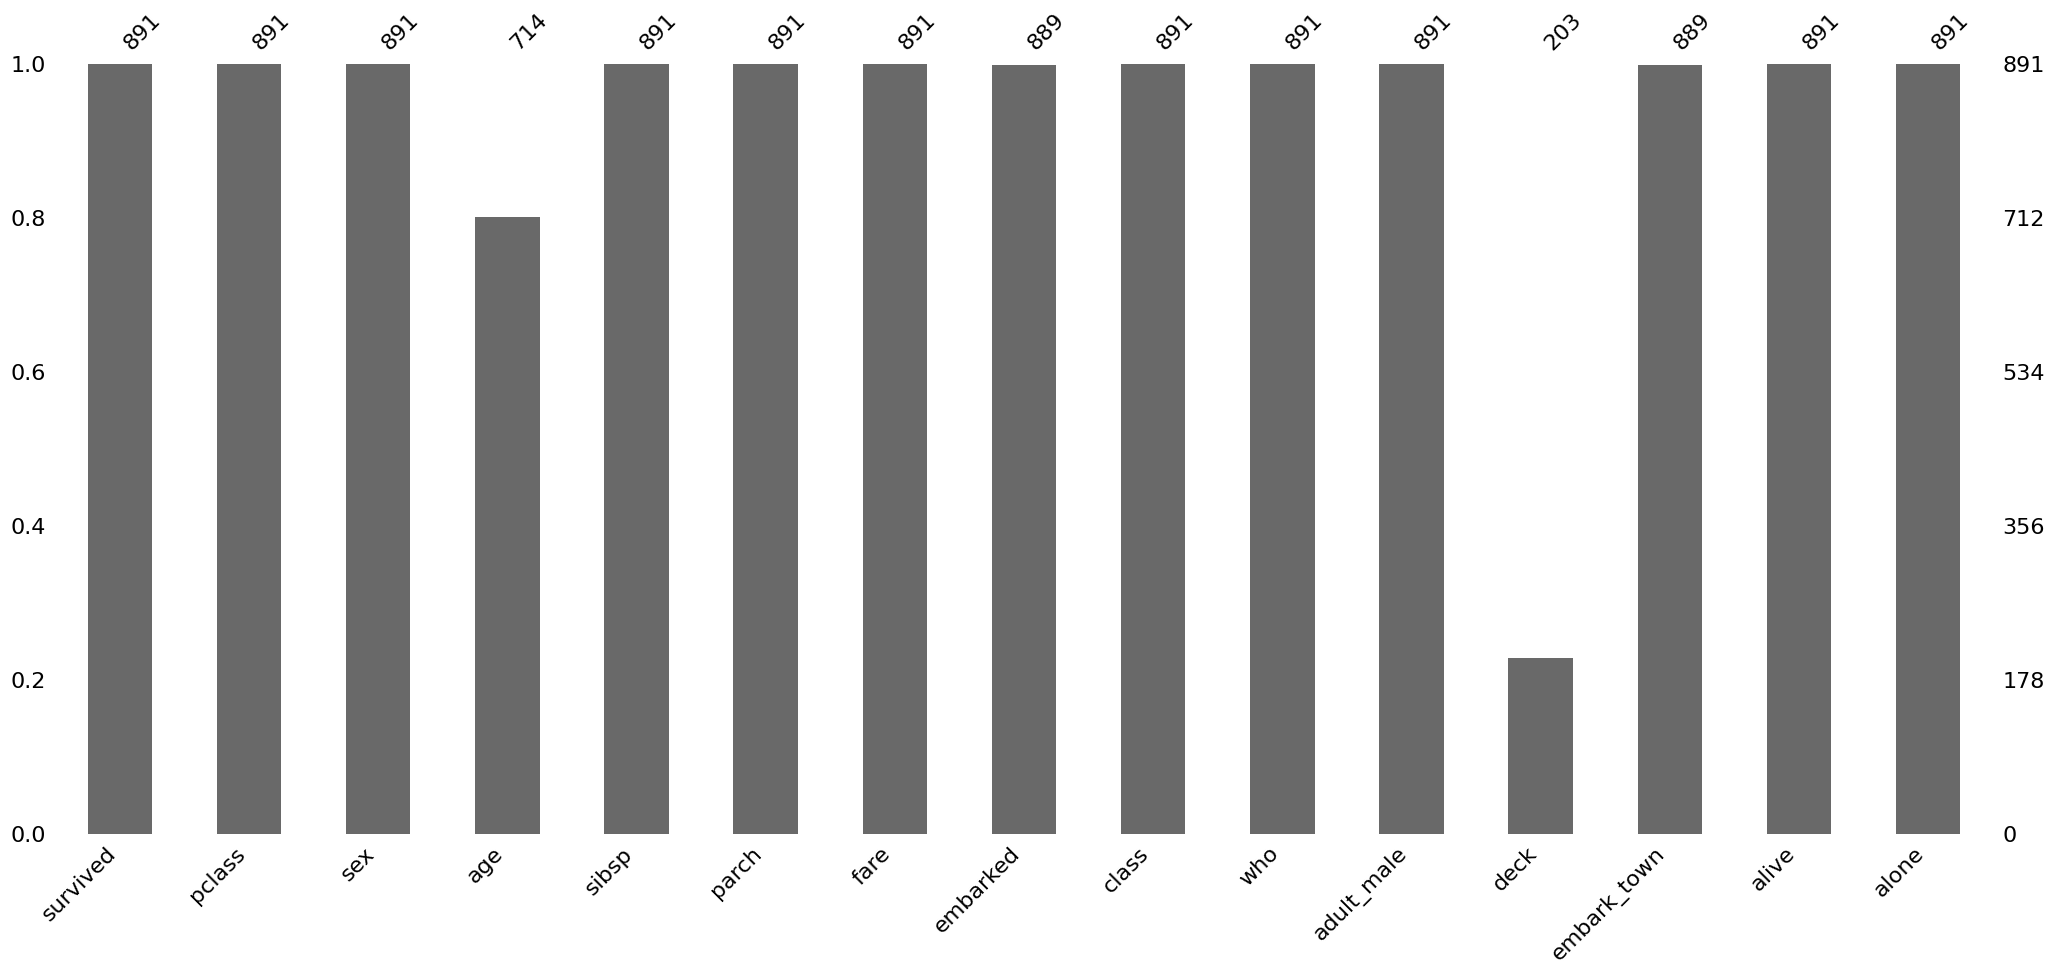

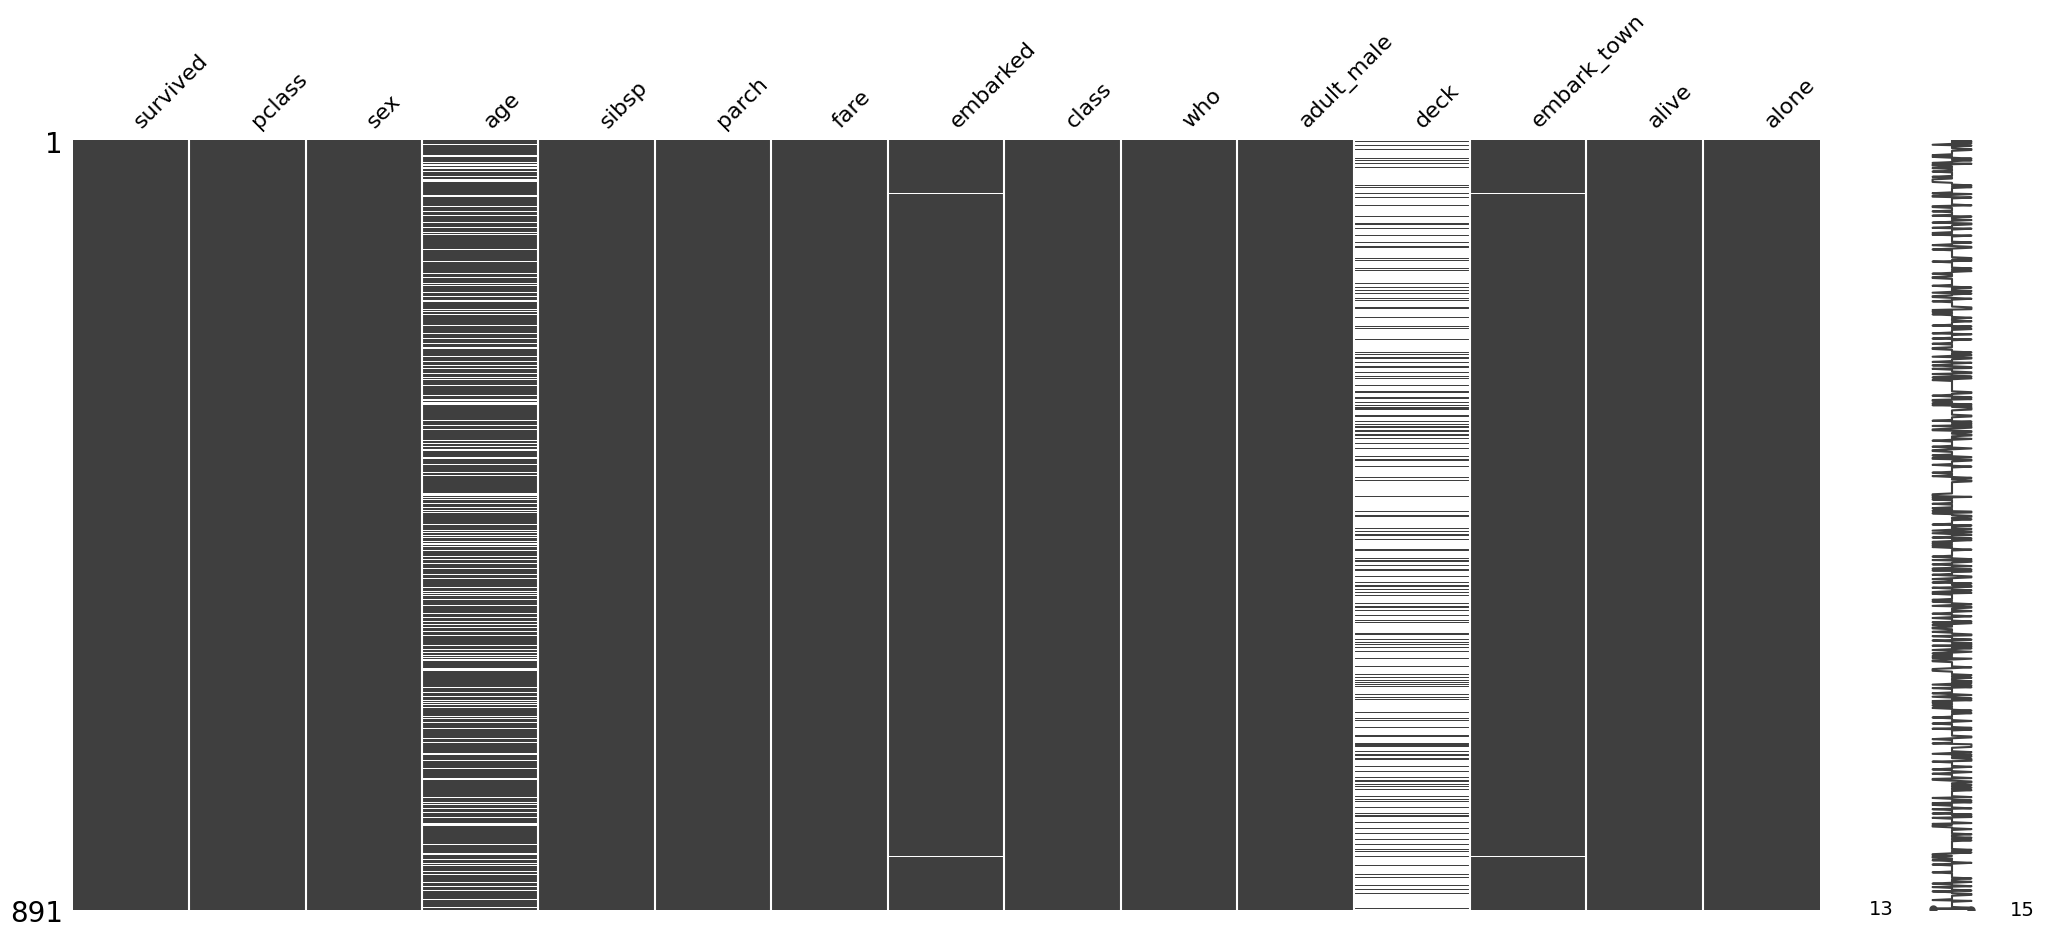

In [58]:
import missingno as msno
# visualization of available/missing data
msno.bar(titanic)
msno.matrix(titanic)

### Removing data
We have discussed that removing data is typically not ideal, but nothing stops us from doing that...

In [59]:
# retaining titanic dataset with complete data
titanic_agecomp = titanic.dropna(subset='age', how='any')
titanic_agecomp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     714 non-null    int64   
 1   pclass       714 non-null    int64   
 2   sex          714 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        714 non-null    int64   
 5   parch        714 non-null    int64   
 6   fare         714 non-null    float64 
 7   embarked     712 non-null    object  
 8   class        714 non-null    category
 9   who          714 non-null    object  
 10  adult_male   714 non-null    bool    
 11  deck         184 non-null    category
 12  embark_town  712 non-null    object  
 13  alive        714 non-null    object  
 14  alone        714 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 70.2+ KB


In [60]:
# comparing the correlation with / without missing data
corr = titanic.select_dtypes('number').corr()
corr_agecomp = titanic_agecomp.select_dtypes('number').corr()

# changes in correlation matrix with / without age missingness
corr - corr_agecomp

,survived,pclass,age,sibsp,parch,fare
survived,0.000,0.021,0.0,-0.018,-0.012,-0.011
pclass,0.021,0.000,0.0,0.016,-0.007,0.005
age,0.000,0.000,0.0,0.000,0.000,0.000
sibsp,-0.018,0.016,0.0,0.000,0.031,0.021
parch,-0.012,-0.007,0.0,0.031,0.000,0.011
fare,-0.011,0.005,0.0,0.021,0.011,0.000


In [61]:
# one other possibility (that includes boolean)

# changes in correlation matrix with / without age missingness

### Simple imputation with a constant

In [62]:
# !pip install scikit-learn
from sklearn.impute import SimpleImputer

<Axes: xlabel='age', ylabel='Count'>

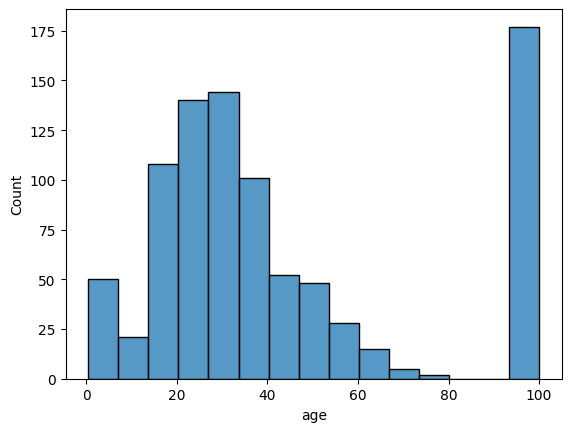

In [63]:
titanic_constant = titanic.copy()

# set constant, completing data
constant_imputer = SimpleImputer(strategy='constant')
constant_imputer.fill_value = 100

titanic_constant['age'] = constant_imputer.fit_transform(titanic_constant[['age']])

# visualize completed data
sns.histplot(titanic_constant['age'])

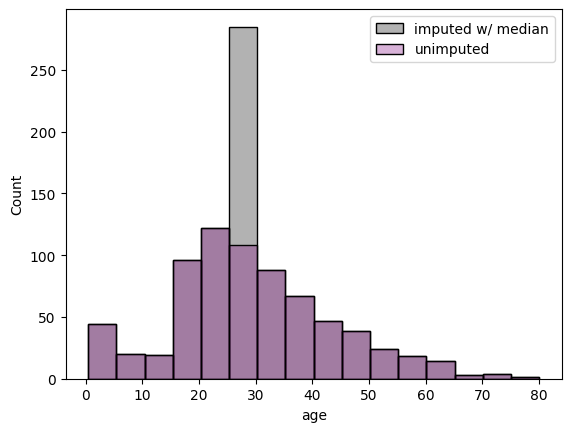

In [64]:
titanic_median = titanic.copy()

# example with median, admitting only numeric columns
median_imputer = SimpleImputer(strategy='median')
titanic_median = titanic.copy()
titanic_median['age'] = median_imputer.fit_transform(titanic_median[['age']])


# visualize completed data
fig, ax = plt.subplots(1, 1)
sns.histplot(titanic_median['age'], binwidth=5, alpha=0.3, color='k', label='imputed w/ median')
sns.histplot(titanic['age'], binwidth=5, alpha=0.3, color='purple', label='unimputed')
ax.legend()

### Multiple imputation
Multiple imputation is a technique to generate multiple realizations of imputation values, often modeled by a probability distribution.

One method is the multiple imputation by chained equations, or MICE. `miceforest` uses LightBGM as its training algorithm for MICE.

In [65]:
# !pip install -U miceforest plotnine

In [66]:
import miceforest as mf

# miceforest requires a real matrix.
# For illustrative purposes, we only use the numerical columns.

# set up a kernel to produce `num_datasets` imputed datasets
num_datasets = 4
kernel = mf.ImputationKernel(
  titanic.select_dtypes('number'),
  num_datasets=num_datasets,
  save_all_iterations_data=False,
  random_state=1
)

In [67]:
# run the MICE algorithm
kernel.mice(iterations=10)


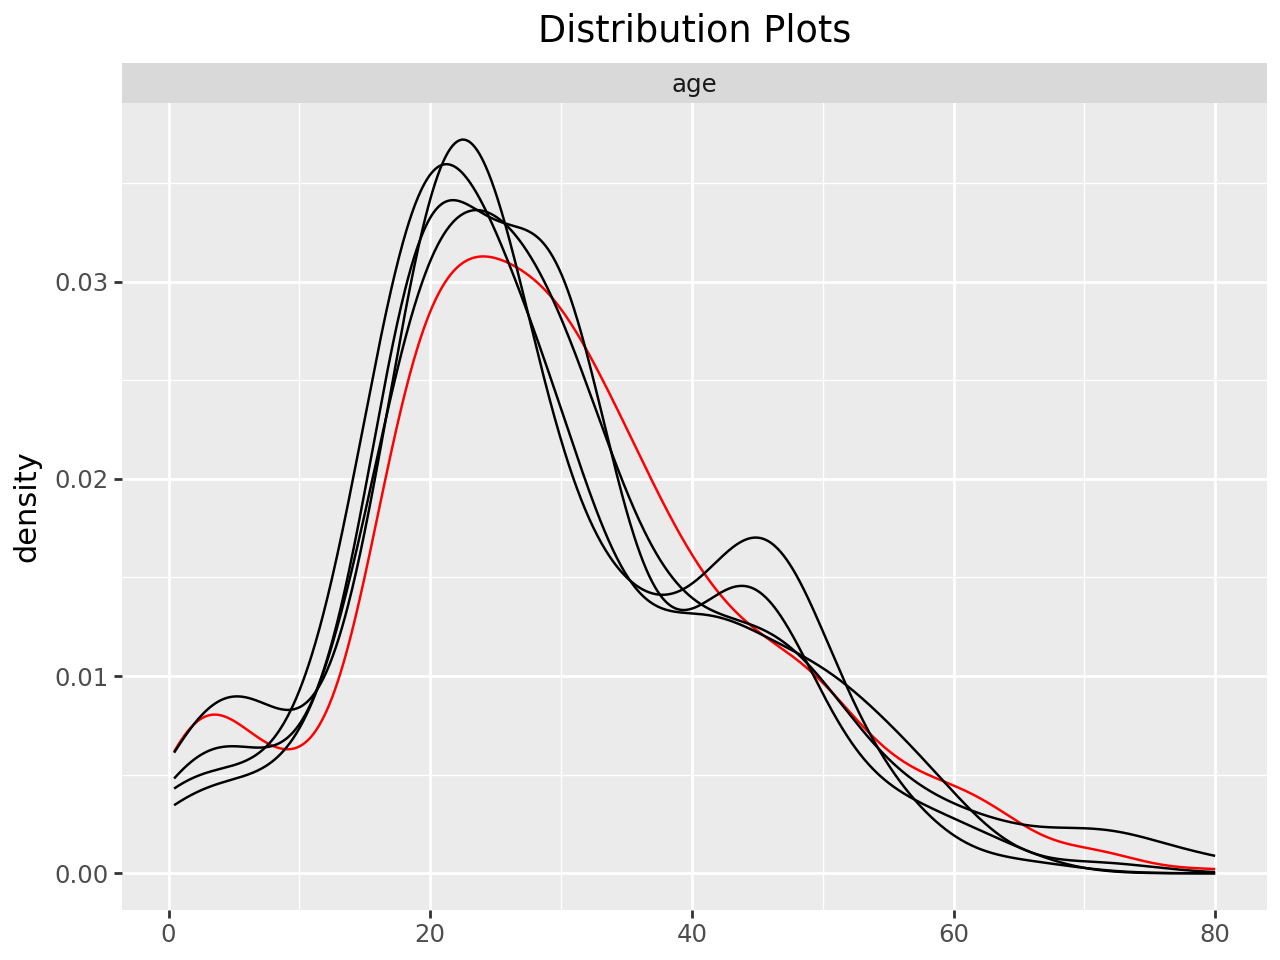

In [68]:

kernel.plot_imputed_distributions()

# candidate num = 3 v. 200
# 200 - creates a smoother, less variability, more stable plot, more candidates predict the same outcome, smoother distribution
# 3 - curvier, rougher, more variability
# which is better? - it depends
    # 3 - smooth version of histogram. babies in the dataset are still being represented
    # 200 - downscaled the baby population. downscaled the elderly population. (the two ends of the plot are less crazier)
    # are you trying to look at an analysis that tells you about overall population? (choose 200 - average analysis) or everybody in the dataset (choose 3 - more variability, but more representative)

# imputation in general is done when you have a question you're trying to answer


In [69]:
# retrieve completed data
titanic_mf = kernel.complete_data
titanic_mf

<bound method ImputedData.complete_data of 
              Class: ImputationKernel
            Datasets: 4
          Iterations: 10
        Data Samples: 891
        Data Columns: 6
   Imputed Variables: 1
   Modeled Variables: 1
All Iterations Saved: False
        >

In [70]:
# code for plotting mice completed dataset
def plot_hist(kernel, completed_titanic, original_titanic, num_plot):
    num_datasets = kernel.num_datasets
    num_plot = min(num_datasets, num_plot)
    for k in range(num_plot):  # 1, 2, 3, num_datasets
        sns.histplot(completed_titanic(dataset=k)['age'], binwidth=5, stat='probability', color='k', label='imputed sample', alpha=0.3)

    sns.histplot(original_titanic['age'], binwidth=5, stat='probability', color='purple', label='unimputed', alpha=0.2)

    plt.title('{:d} realizations of imputed age'.format(num_plot))
    plt.legend()
    plt.tight_layout()
    plt.show()

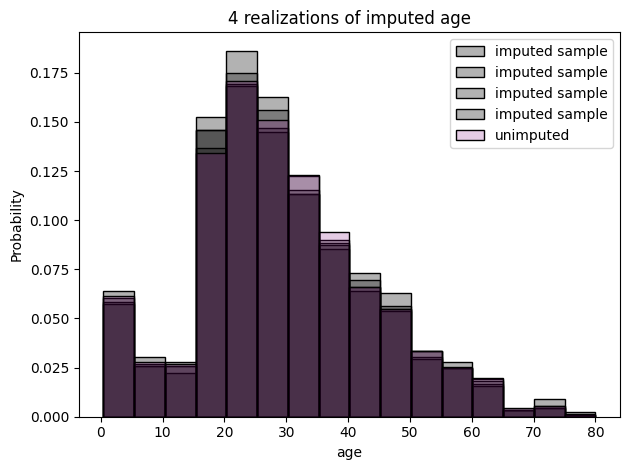

In [71]:
# retrieving each imputed dataset (recall that M in MICE means multiple)
import matplotlib.pyplot as plt

plot_hist(kernel=kernel, completed_titanic=titanic_mf, original_titanic=titanic, num_plot=num_datasets)

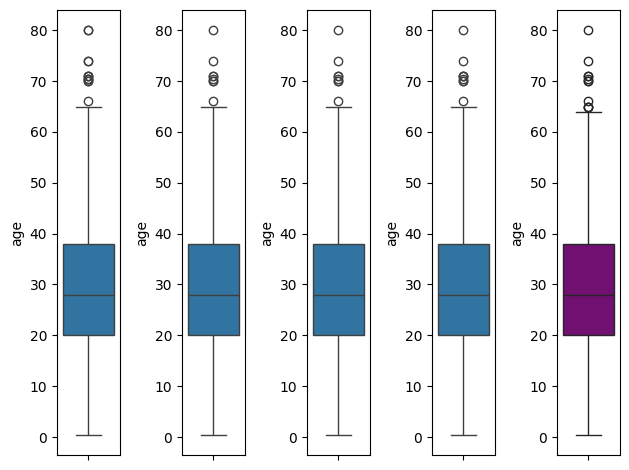

In [72]:
# comparing the original and imputed dataset
fig, ax = plt.subplots(ncols=5)

for k, axi in enumerate(ax.flatten()):
    if k < num_datasets:
        sns.boxplot(titanic_mf(dataset=k)['age'], ax=axi)
    else:
        sns.boxplot(titanic['age'], ax=axi, color='purple')

plt.tight_layout()
plt.show()

In [73]:
# Generate more datasets

# Visualize the result variable density/histogram

### Predictive mean matiching (MICE) [Last figure in the gas consumption example]

In [74]:
kernel_pmm = mf.ImputationKernel(
    data=titanic.select_dtypes('number'),
    num_datasets=num_datasets,
    mean_match_candidates=5,
    random_state=1,
    save_all_iterations_data=False
)

In [75]:
kernel_pmm.mice(iterations=15)


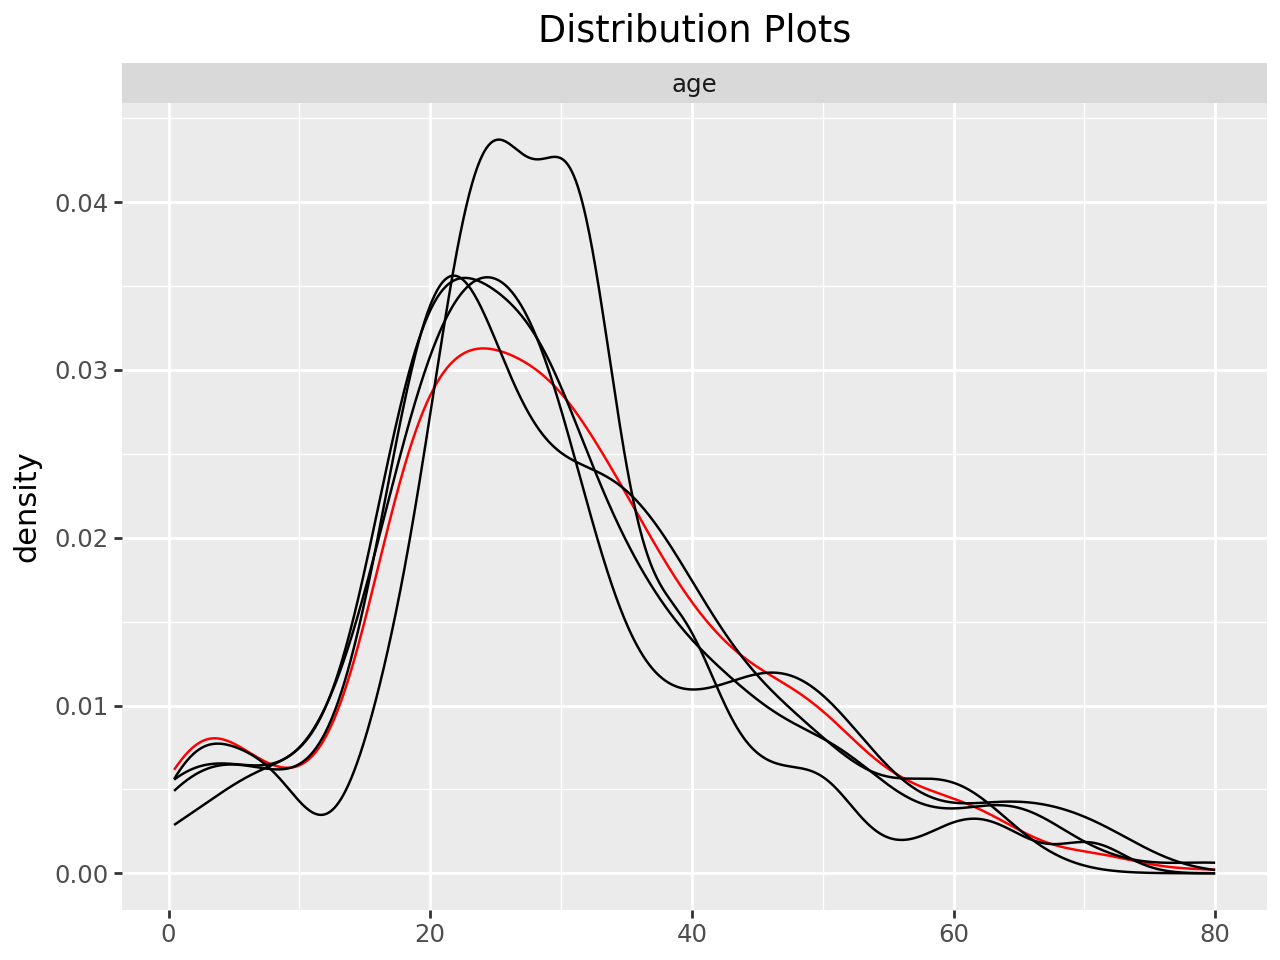

In [76]:
kernel_pmm.plot_imputed_distributions()


In [77]:
titanic_pmm = kernel_pmm.complete_data


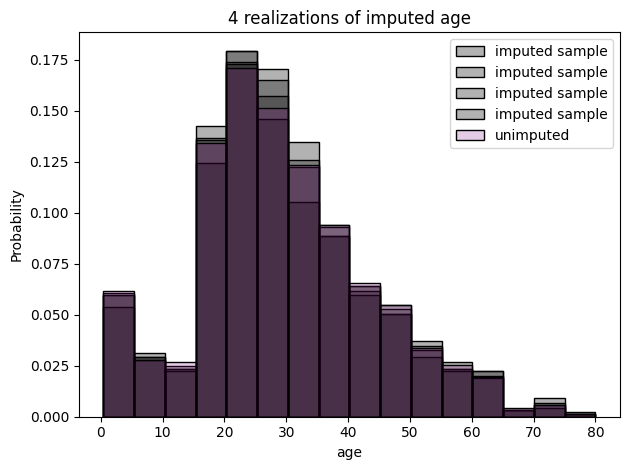

In [78]:
plot_hist(kernel=kernel, completed_titanic=titanic_pmm, original_titanic=titanic, num_plot=4)


Gradient boosting:

**boosting a model** - takes a model, and when you predict, you get errors. boosting model takes the residuals (errors) and fits another model. wherever you're not doing well in the first model, you're gonna do better in the second model.

as you add more and more boosting models, you tackle all of the residuals as you go forward. more models = covering more errors

### $k$ Nearest Neighbor

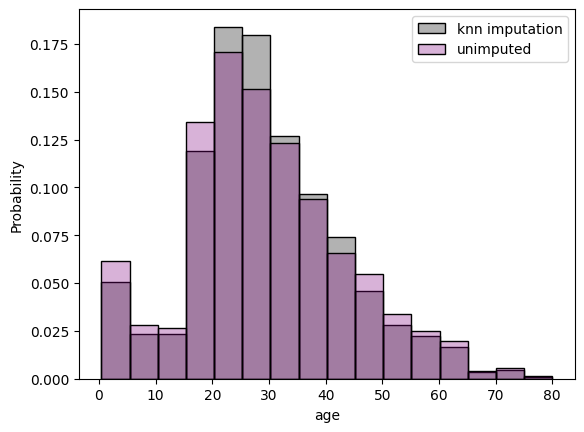

In [79]:
from sklearn.impute import KNNImputer
titanic_knn = titanic.select_dtypes('number').copy()

knn_imputer = KNNImputer(n_neighbors=3)
titanic_knn_impute = knn_imputer.fit_transform(titanic_knn)
titanic_knn_df = pd.DataFrame(titanic_knn_impute, columns=titanic_knn.columns)

fig, ax = plt.subplots(1, 1)
sns.histplot(titanic_knn_df['age'], binwidth=5, stat='probability', alpha=0.3, color='k', label='knn imputation')
sns.histplot(titanic['age'], binwidth=5, stat='probability', alpha=0.3, color='purple', label='unimputed')
ax.legend()

How to analyze data when info is missing

Understand why the data is missing. Fill in the gaps to create results

1. different ways to fill in the missing data
- mean - fills gaps with average
- pmm - finds existing row that's most similar to the missing row and borrows its value

## (Exercise) Imputation of tips

Consider the `taxis` dataset from seaborn, practice the imputation methods on the `tip` column for the dataset `subtaxi_missing`, given below:

1. Complete the data using         
    i. mean simple imputation,
    ii. median simple imputation,
    iii. k-nearest neighbor, and
    iv. predictive mean matching.
2. Compute the root mean squared error for each imputation method (because you know the truth).  Which one is the best in this case?
3. Examine the correlation matrix among the numerical columns.  Which methods preserve the correlation among variables?

In [80]:
import seaborn as sns

taxi = sns.load_dataset('taxis')
taxi.info()
subtaxi = taxi.loc[:, ['passengers', 'distance', 'fare', 'tip', 'tolls', 'total']]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [81]:
import numpy as np
# create missingness
np.random.seed(42)
mask1 = subtaxi.total > 25
mask2 = np.random.rand(subtaxi.shape[0]) < 0.7

subtaxi_missing = subtaxi.copy()
subtaxi_missing.loc[mask1 & mask2, 'tip'] = np.nan

<Axes: >

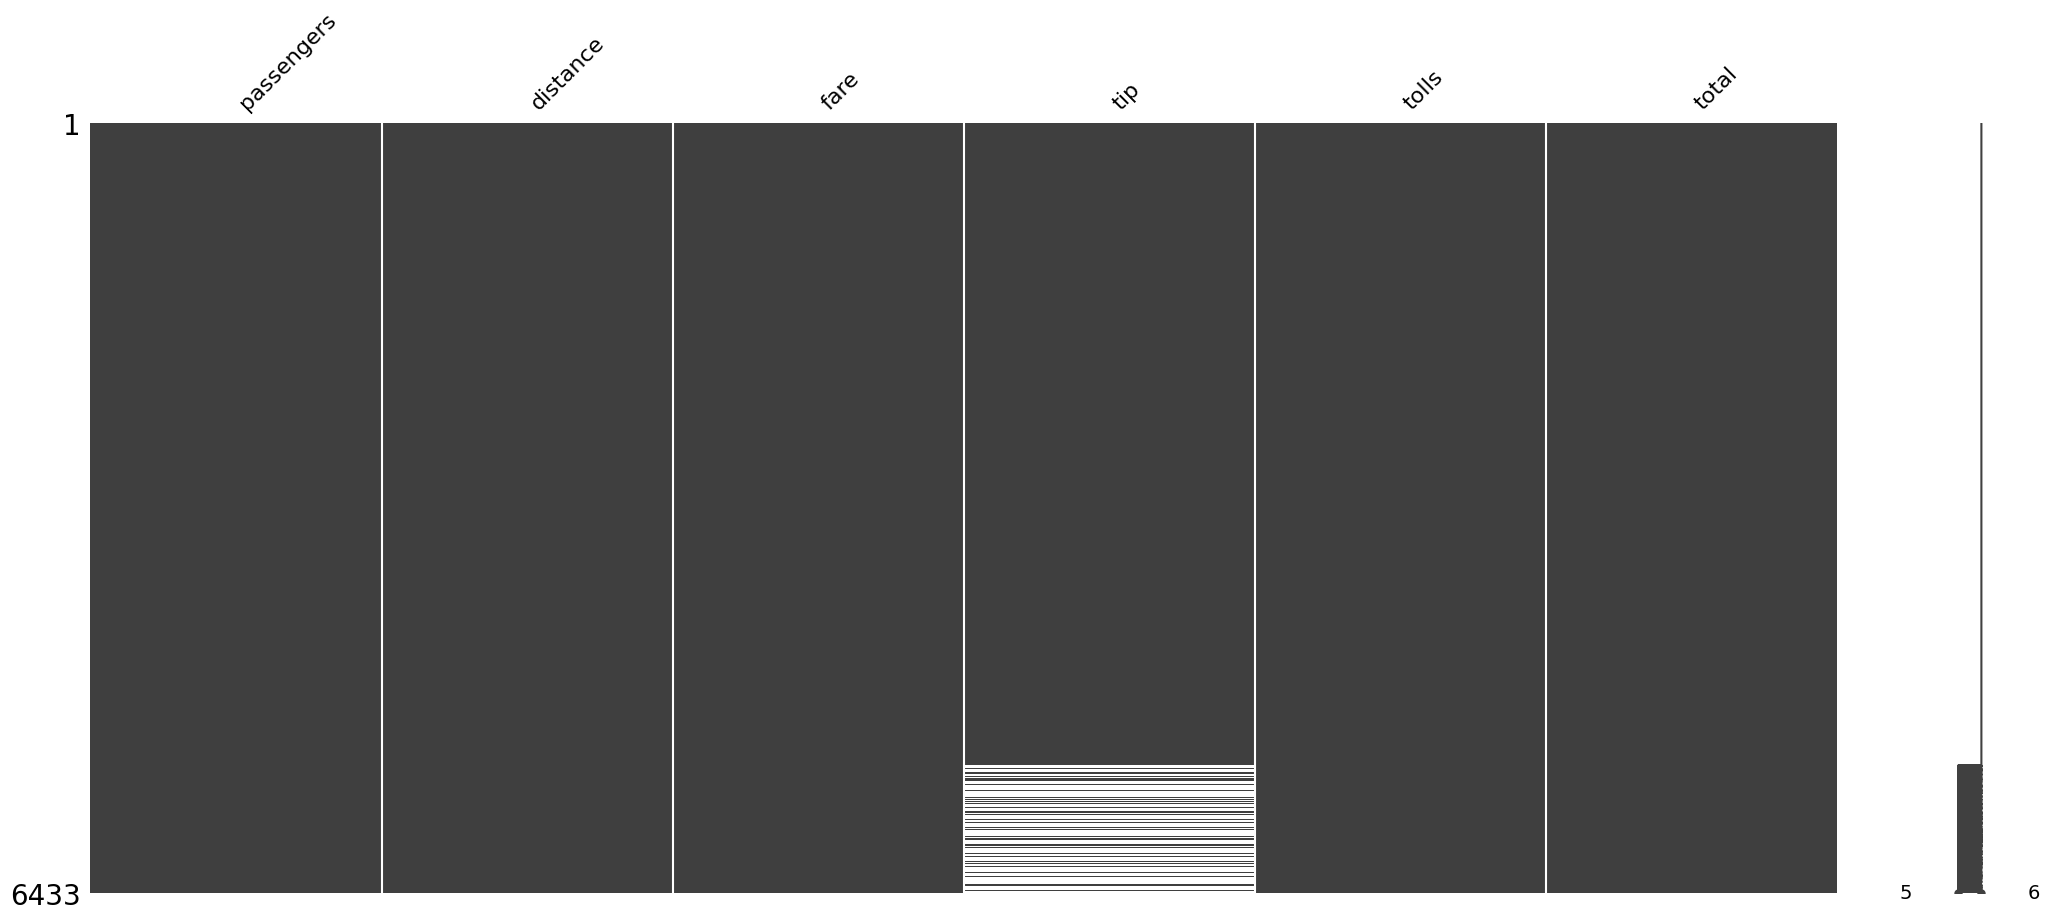

In [82]:
msno.matrix(subtaxi_missing.sort_values('total'))

# visualize and see the missing tip values

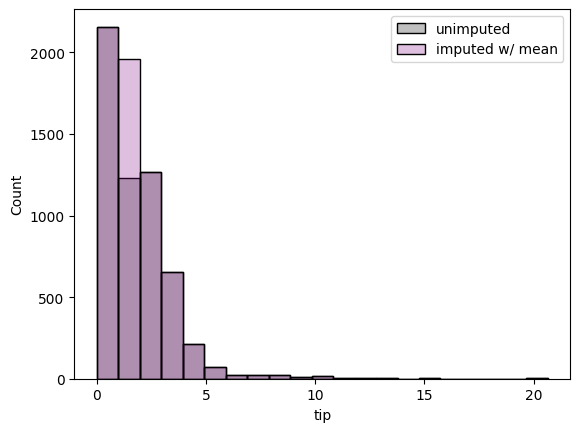

In [83]:
# Mean Simple Imputation
mean_imputer = SimpleImputer(strategy='mean')
subtaxi_mean = subtaxi_missing.copy()
subtaxi_mean['tip'] = mean_imputer.fit_transform(subtaxi_mean[['tip']])

fig, ax = plt.subplots(1, 1)
sns.histplot(subtaxi_missing['tip'], binwidth=1, alpha=0.25, color='k', label='unimputed')
sns.histplot(subtaxi_mean['tip'], binwidth=1, alpha=0.25, color='purple', label='imputed w/ mean')
# sns.histplot(subtaxi_mean['tip'], binwidth=5, alpha=0.25, color='k', label='imputed w/ mean')
ax.legend()

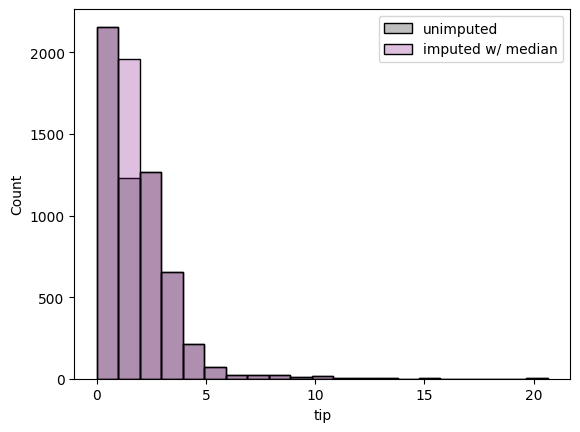

In [84]:
# Median Simple Imputation

median_imputer = SimpleImputer(strategy='median')
subtaxi_median = subtaxi_missing.copy()
subtaxi_median['tip'] = median_imputer.fit_transform(subtaxi_median[['tip']])

fig, ax = plt.subplots(1, 1)
sns.histplot(subtaxi_missing['tip'], binwidth=1, alpha=0.25, color='k', label='unimputed')
sns.histplot(subtaxi_median['tip'], binwidth=1, alpha=0.25, color='purple', label='imputed w/ median')
# sns.histplot(subtaxi_mean['tip'], binwidth=5, alpha=0.25, color='k', label='imputed w/ mean')
ax.legend()

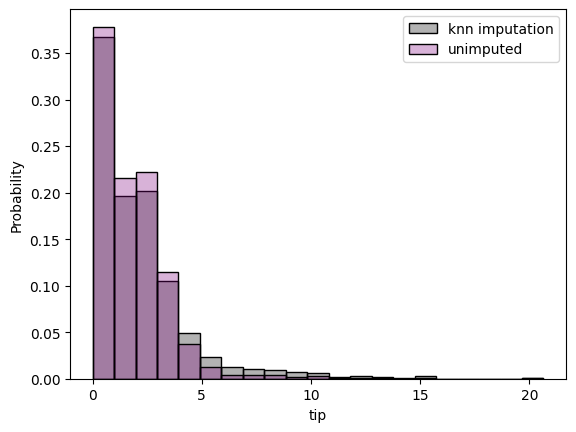

In [85]:
# KNN
from sklearn.impute import KNNImputer
subtaxi_knn = subtaxi_missing.select_dtypes('number').copy()

knn_imputer = KNNImputer(n_neighbors=3)
subtaxi_knn_impute = knn_imputer.fit_transform(subtaxi_knn)
subtaxi_knn_df = pd.DataFrame(subtaxi_knn_impute, columns=subtaxi_knn.columns)

fig, ax = plt.subplots(1, 1)
sns.histplot(subtaxi_knn_df['tip'], binwidth=1, stat='probability', alpha=0.3, color='k', label='knn imputation')
sns.histplot(subtaxi_missing['tip'], binwidth=1, stat='probability', alpha=0.3, color='purple', label='unimputed')
ax.legend()

# imputed values are spread out
# overall shape of data is preserved
# use probability to normalize the data and actually see if its better

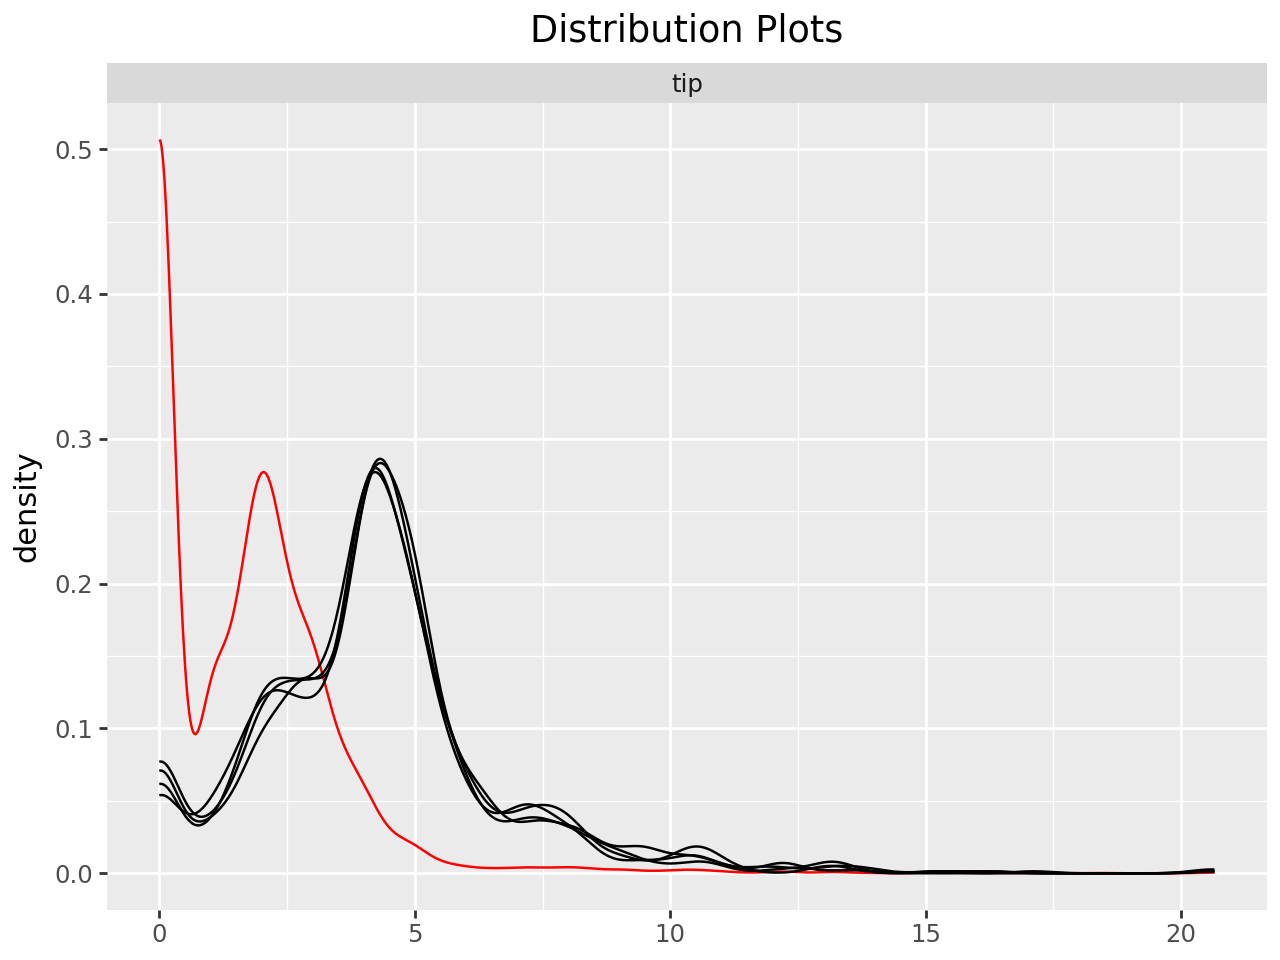

In [86]:
# PMM
kernel_pmm = mf.ImputationKernel(
    data=subtaxi_missing.select_dtypes('number'),
    num_datasets=num_datasets, # number of versions of dataset to be created
    mean_match_candidates=200, # how many similar observations it finds
    random_state=1,
    save_all_iterations_data=False
)

kernel_pmm.mice(iterations=5)

subtaxi_pmm = kernel_pmm.complete_data(dataset=0)

kernel_pmm.plot_imputed_distributions()

In [87]:
# Compute the root mean squared error for each imputation method (because you know the truth).
# Which one is the best in this case?

from sklearn.metrics import mean_squared_error
import numpy as np

is_missing_data = subtaxi_missing['tip'].isna()
original_subtaxi = subtaxi.loc[is_missing_data, 'tip']

# MSE for Mean imputation
print(f"MSE for Mean imputation: {np.sqrt(mean_squared_error(original_subtaxi, subtaxi_mean['tip'][is_missing_data]))}")

# MSE for Median imputation
print(f"MSE for Median imputation: {np.sqrt(mean_squared_error(original_subtaxi, subtaxi_median['tip'][is_missing_data]))}")

# MSE for knn imputation
print(f"MSE for knn imputation: {np.sqrt(mean_squared_error(original_subtaxi, subtaxi_knn_df['tip'][is_missing_data]))}")

# MSE for pmm imputation
print(f"MSE for pmm imputation: {np.sqrt(mean_squared_error(original_subtaxi, subtaxi_pmm['tip'][is_missing_data]))}")

MSE for Mean imputation: 5.307378280858196
MSE for Median imputation: 5.351210673964779
MSE for knn imputation: 2.0753744591679917
MSE for pmm imputation: 3.4290817889319407


K-Nearest Neighbors is the best, has the lowest error.

**Mean and median were bad** - just removed tips from high-fare rides, so missing tips were systematically large. Computed mean and median from all observed tips which are biased towards small tips from cheap rides. - consistently underestimate the missing values

**knn** - is able to represent the strong linear relationship between tip, fare, and total (averages actual tip values from nearest neighbors).

In [88]:
# Examine the correlation matrix among the numerical columns.
 # (shows correlatoin coefficiet between every pair of columns in dataset)
# Which methods preserve the correlation among variables?

print("Original Correlation matrix: ")
print(subtaxi.select_dtypes('number').corr().round(3))
print("")

print("Mean Correlation matrix: ")
print(subtaxi_mean.corr().round(3))
print("")

print("Median Correlation matrix: ")
print(subtaxi_median.corr().round(3))
print("")

print("KNN Correlation matrix: ")
print(subtaxi_knn_df.corr().round(3))
print("")

print("PMM Correlation matrix: ")
print(subtaxi_pmm.corr().round(3))

Original Correlation matrix: 
            passengers  distance   fare    tip  tolls  total
passengers       1.000     0.009  0.008  0.021 -0.003  0.016
distance         0.009     1.000  0.920  0.453  0.635  0.905
fare             0.008     0.920  1.000  0.489  0.609  0.974
tip              0.021     0.453  0.489  1.000  0.414  0.646
tolls           -0.003     0.635  0.609  0.414  1.000  0.683
total            0.016     0.905  0.974  0.646  0.683  1.000

Mean Correlation matrix: 
            passengers  distance   fare    tip  tolls  total
passengers       1.000     0.009  0.008  0.021 -0.003  0.016
distance         0.009     1.000  0.920  0.240  0.635  0.905
fare             0.008     0.920  1.000  0.263  0.609  0.974
tip              0.021     0.240  0.263  1.000  0.211  0.383
tolls           -0.003     0.635  0.609  0.211  1.000  0.683
total            0.016     0.905  0.974  0.383  0.683  1.000

Median Correlation matrix: 
            passengers  distance   fare    tip  tolls  total

**mean + median imputation** - worst, cuts all tip correlations pretty much in half. destroyed the relationship between tip and the other columns

**knn + pmm** - preserve the correlations well, stayed close to the original coefficient values. pmm overcorrects (higher values) and knn is slightly under. both preserved the structure of the data pretty well



## (Exercise) Imputation of crop recommendation
Investigate the dataset for crop recommendation.

1. Create a function that can induce some missingness (start with missing completely at random).
2. Create a logistic regression model (or any prediction model) for the column `label`.
3. Create a function that can take in an "imputation type" argument and return an imputed dataset.
4. Compare the different imputation types in prediction accuracy of `label` and correlation conservation.



In [ ]:
import pandas as pd
crop = pd.read_csv('https://raw.githubusercontent.com/mosesyhc/de300-2026wi/refs/heads/main/datasets/crop_recommendation.csv')

# References

- Daniel, R. M., Kenward, M. G., Cousens, S. N., & De Stavola, B. L. (2012). Using causal diagrams to guide analysis in missing data problems. Statistical methods in medical research, 21(3), 243-256.  
- Hastie, T., Mazumder, R., Lee, J. D., & Zadeh, R. (2015). Matrix completion and low-rank SVD via fast alternating least squares. The Journal of Machine Learning Research, 16(1), 3367-3402.  
- Little, R. J., & Rubin, D. B. (2019). Statistical analysis with missing data. John Wiley & Sons.  
- [Van Buuren, S. (2012). Flexible imputation of missing data. Boca Raton, FL: CRC press.](https://stefvanbuuren.name/fimd)

# Some useful additional resources

- [Gary King: Analyzing Incomplete Political Science Data](https://gking.harvard.edu/files/evil.pdf)
- Zangerle, E., & Bauer, C. (2022). Evaluating recommender systems: survey and framework. ACM Computing Surveys, 55(8), 1-38.